In [1]:
import slangpy as spy
from pyglm import glm
import matplotlib.pyplot as plt
import numpy as np
import quaternion
from PIL import Image
import pathlib
import jax
import jax.numpy as jnp


from bvhgs import device
from bvhgs.camera import Camera
from bvhgs.gaussian import GaussianCloud
from bvhgs.renderer import Renderer
from bvhgs.prefix_sum import prefix_sum
from bvhgs.radix_sort import radix_sort, numpy_sort
from bvhgs.data import SFMDataset

[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] No supported shader model found, pretending to support sm_6_0.


In [2]:
np.random.seed(0)

# Load Gaussian Buffer

In [3]:
gaussians = GaussianCloud()
gaussians.load_from_colmap(pathlib.Path("../resources/dataset/tandt_db/tandt/truck/sparse/0/"), scale_factor=-5)
len(gaussians)

104692

# Load Module and Shader

In [4]:
module = device.load_module("renderer.slang")
module

SlangModule(
  name = renderer.slang,
  path = /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/renderer.slang,
  entry_points = [
    SlangEntryPoint(name="project", stage=compute),
    SlangEntryPoint(name="cull", stage=compute),
    SlangEntryPoint(name="bwdCullProjection", stage=compute),
    SlangEntryPoint(name="computeTile", stage=compute),
    SlangEntryPoint(name="buildGaussianTable", stage=compute),
    SlangEntryPoint(name="tileHistogram", stage=compute),
    SlangEntryPoint(name="duplicateGaussian", stage=compute),
    SlangEntryPoint(name="rasterize", stage=compute),
    SlangEntryPoint(name="bwdDuplicateGaussian", stage=compute),
    SlangEntryPoint(name="bwdRasterize", stage=compute),
    SlangEntryPoint(name="extractSortedGaussianGrad", stage=compute),
    SlangEntryPoint(name="gradDescentGaussian2D", stage=compute),
  ]
)

In [5]:
program = device.link_program([module], [])
program

ShaderProgram(
  modules = [
    SlangModule(
      name = renderer.slang,
      path = /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/renderer.slang,
      entry_points = [
        SlangEntryPoint(name="project", stage=compute),
        SlangEntryPoint(name="cull", stage=compute),
        SlangEntryPoint(name="bwdCullProjection", stage=compute),
        SlangEntryPoint(name="computeTile", stage=compute),
        SlangEntryPoint(name="buildGaussianTable", stage=compute),
        SlangEntryPoint(name="tileHistogram", stage=compute),
        SlangEntryPoint(name="duplicateGaussian", stage=compute),
        SlangEntryPoint(name="rasterize", stage=compute),
        SlangEntryPoint(name="bwdDuplicateGaussian", stage=compute),
        SlangEntryPoint(name="bwdRasterize", stage=compute),
        SlangEntryPoint(name="extractSortedGaussianGrad", stage=compute),
        SlangEntryPoint(name="gradDescentGaussian2D", stage=compute),
      ]
    ),
  ],
  entry_points = []
)

# Build Slang Buffer and Camera Parameter

In [6]:
# Create a buffer for the Gaussian points.
gaussian_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_gaussian_3d,
    usage=spy.BufferUsage.shader_resource,
)
# Store all the gaussian points in the buffer.
gaussian_cursor = spy.BufferCursor(
    program.reflection.g_gaussian_3d.type_layout.element_type_layout,
    gaussian_buf,
)

for i in range(len(gaussians)):
    gaussian_cursor[i].write(gaussians[i])
gaussian_cursor.apply()

In [7]:
sfm_dataset = SFMDataset()
sfm_dataset.load_from_colmap(
    colmap_path=pathlib.Path("../resources/dataset/tandt_db/tandt/truck/sparse/0/"),
    image_dir=pathlib.Path("../resources/dataset/tandt_db/tandt/truck/images/")
)

{'_rotation': [-0.036209676414728165, 0.9839765429496765, 0.17386838793754578, -0.01577397622168064], '_translation': vec3( -0.225826, -1.05851, 5.25607 ), '_sensorSize': uvec2( 979, 546 ), '_focalLength': 581.9245354745742, '_nearPlane': 0.1, '_farPlane': 1000.0}


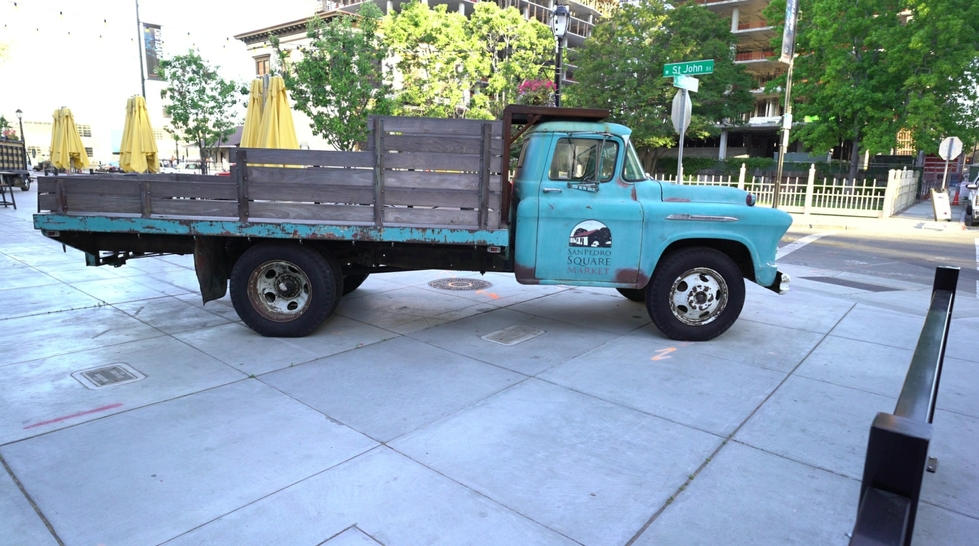

In [8]:
camera, image_path = sfm_dataset[0]
print(camera.to_slang())
image = Image.open(image_path)
image

# Projection

## Dispatch Projection Kernel

In [9]:
# Create a buffer for the Gaussian2D points.
gaussian2d_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_gaussian_2d,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian2d_buf

Buffer(
  device = 0x13424fc28,
  size = 8375360,
  struct_size = 80,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 7.99 MB,
  label = 
)

In [10]:
# Create flag buffer for culling.
inside_flag_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_inside_flag,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
inside_flag_buf

Buffer(
  device = 0x13424fc28,
  size = 418768,
  struct_size = 4,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 408.95 kB,
  label = 
)

In [11]:
ker_proj = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("project")])
)
ker_proj

ComputeKernel(0x332b3e0c0)

In [12]:
ker_proj.dispatch(
    thread_count=[len(gaussians), 1, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_gaussian_3d": gaussian_buf,
        "g_gaussian_2d": gaussian2d_buf,
        "g_inside_flag": inside_flag_buf
    }
)

In [13]:
cursor = spy.BufferCursor(
    program.reflection.g_gaussian_2d.type_layout.element_type_layout,
    gaussian2d_buf,
)
cursor.element_count
cursor[0]

{'position': {0.3242423, 0.34090775, 0.003679035}, 'covariance': {{1.1234304e-06, -1.8672728e-14}, {-2.3362022e-14, 3.6118206e-06}}, 'color': {0.27344006, 0.3125016, 0.35546938}, 'opacity': 0.5, 'cachedInvCov': {{890130.9, 0.004601882}, {0.0057575554, 276868.7}}} [Gaussian2D]

## Cull Gaussians

In [14]:
ker_cull = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("cull")])
)

In [15]:
# Cull the Gaussian points.
inside_offset_buf = prefix_sum(inside_flag_buf)
inside_offset_cursor = spy.BufferCursor(
    program.reflection.g_inside_offset.type_layout.element_type_layout,
    inside_offset_buf,
)
# Read the last element of the cull prefix buffer to get the number of culled points.
num_viewing = int(inside_offset_cursor[len(inside_offset_cursor) - 1].read())  # type: ignore
num_viewing

97005

In [16]:
# Culled gaussians
culled_gaussian_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.g_gaussian_2d_culled,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
culled_gaussian_buf

Buffer(
  device = 0x13424fc28,
  size = 7760400,
  struct_size = 80,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 7.40 MB,
  label = 
)

In [17]:
ker_cull.dispatch(
    thread_count=[len(gaussians), 1, 1],
    vars={
        "g_gaussian_2d": gaussian2d_buf,
        "g_inside_flag": inside_flag_buf,
        "g_inside_offset": inside_offset_buf,
        "g_gaussian_2d_culled": culled_gaussian_buf
    }
)

In [18]:
cursor = spy.BufferCursor(
    program.reflection.g_gaussian_2d_culled.type_layout.element_type_layout,
    culled_gaussian_buf,
)
cursor[0]

{'position': {0.3242423, 0.34090775, 0.003679035}, 'covariance': {{1.1234304e-06, -1.8672728e-14}, {-2.3362022e-14, 3.6118206e-06}}, 'color': {0.27344006, 0.3125016, 0.35546938}, 'opacity': 0.5, 'cachedInvCov': {{890130.9, 0.004601882}, {0.0057575554, 276868.7}}} [Gaussian2D]

# Tiling

In [19]:
ker_tile = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("computeTile")])
)
ker_build_gs = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("buildGaussianTable")])
)

In [20]:
num_tile_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.g_num_tiles,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
num_tile_buf

Buffer(
  device = 0x13424fc28,
  size = 388020,
  struct_size = 4,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 378.93 kB,
  label = 
)

In [21]:
ker_tile.dispatch(
    thread_count=[num_viewing, 1, 1],
    numViewing=num_viewing,
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_num_tiles": num_tile_buf
    }
)

In [22]:
num_tile_arr = num_tile_buf.to_numpy().view(np.uint32)
num_table_entries = np.sum(num_tile_arr).item()
num_table_entries

130520

In [23]:
gaussian_table_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.g_gaussian_table,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian_table_buf

Buffer(
  device = 0x13424fc28,
  size = 2088320,
  struct_size = 16,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 1.99 MB,
  label = 
)

In [24]:
num_tile_prefix_buf = prefix_sum(num_tile_buf)

In [25]:
ker_build_gs.dispatch(
    thread_count=[num_viewing, 1, 1],
    numViewing=num_viewing,
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_num_tiles_prefix": num_tile_prefix_buf,
        "g_gaussian_table": gaussian_table_buf,
    }
)

# Sort Tile

In [26]:
numpy_sort(gaussian_table_buf)

In [27]:
ker_tile_hist = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("tileHistogram")])
)

In [28]:
hist_buf = device.create_buffer(
    element_count=2**8,
    struct_type=program.reflection.g_tile_hist_atomic,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)
# Compute the histogram of the Gaussian table.
ker_tile_hist.dispatch(
    thread_count=[num_table_entries, 1, 1],
    numEntries=num_table_entries,
    vars={
        "g_gaussian_table": gaussian_table_buf,
        "g_tile_hist_atomic": hist_buf,
    },
)

[WARN] (rhi) slang: metal 32023.619: /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/./renderer/tile.slang(75): warning :  unused variable '_S1' [-Wunused-variable]
    uint _S1 = atomic_fetch_add_explicit((&kernelContext_0)->g_tile_hist_atomic_0+uint(((*((&kernelContext_0)->g_gaussian_table_0+tid_1)).key_0) >> 32U), 1U, memory_order_relaxed);
         ^
1 warning generated.



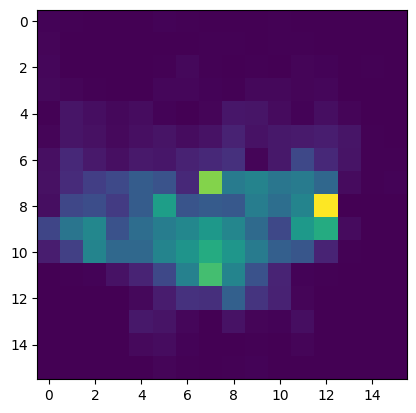

In [29]:
plt.imshow(hist_buf.to_numpy().view(np.uint32).reshape(16, 16))

# Rasterize

In [30]:
ker_duplicate = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("duplicateGaussian")])
)
ker_rasterize = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("rasterize")])
)

In [31]:
gaussian_2d_sorted_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.g_gaussian_2d_sorted,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian_2d_sorted_buf

Buffer(
  device = 0x13424fc28,
  size = 10441600,
  struct_size = 80,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 9.96 MB,
  label = 
)

In [32]:
ker_duplicate.dispatch(
    thread_count=[num_table_entries, 1, 1],
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_gaussian_table": gaussian_table_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf
    }
)

In [33]:
render_target = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

depth_target = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

num_depth_buf = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.r32_uint,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

In [34]:
hist_arr = hist_buf.to_numpy().view(np.uint32)
hist_offs = np.zeros_like(hist_arr)
hist_offs[1:] = np.cumsum(hist_arr)[:-1]

In [35]:
tile_offst_buf = device.create_buffer(
    element_count=len(hist_offs),
    struct_type=program.reflection.g_tile_offs,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
tile_offst_buf.copy_from_numpy(hist_offs)

In [36]:
ker_rasterize.dispatch(
    thread_count=[camera.sensor_size.x, camera.sensor_size.y, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_tile_hist": hist_buf,
        "g_tile_offs": tile_offst_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
        "g_render_target": render_target,
        "g_depth_target": depth_target,
        "g_num_rendered_gaussians": num_depth_buf,
    }
)

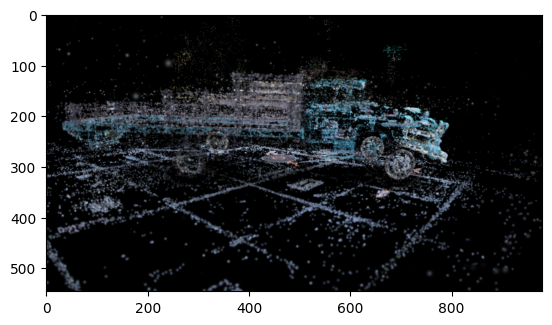

In [37]:
raw_image = jnp.array(render_target.to_numpy()[:, :, :3])
plt.imshow(raw_image)

# Image Loss

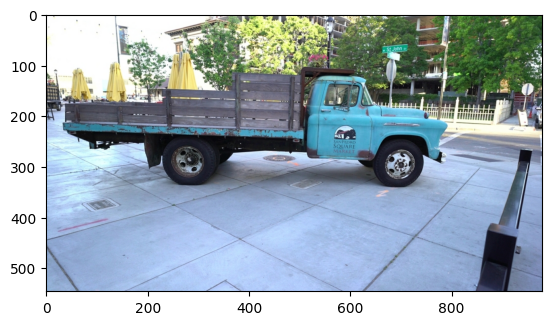

In [38]:
image_arr = jnp.array(image).astype(jnp.float32) / 255.0
plt.imshow(image_arr)

In [39]:
def image_loss(src: jnp.ndarray, dst: jnp.ndarray):
    return jnp.mean((dst - src)**2)

In [40]:
image_loss(raw_image, image_arr)

Array(0.37208068, dtype=float32)

In [41]:
# Image grad.
loss_grad = jax.value_and_grad(image_loss)

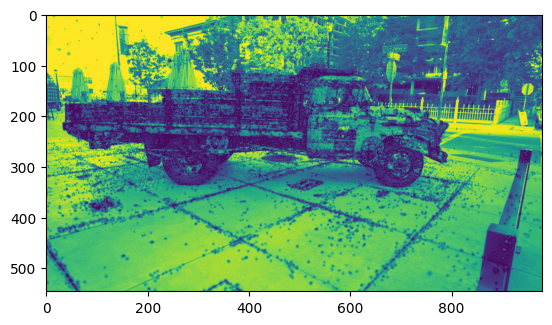

In [42]:
loss, render_target_grad = loss_grad(raw_image, image_arr)
plt.imshow(jnp.linalg.norm(render_target_grad, axis=-1))

In [43]:
render_target_grad.shape

(546, 979, 3)

In [44]:
rg_shape = render_target_grad.shape
render_target_grad = jnp.concatenate((render_target_grad, jnp.zeros((rg_shape[0], rg_shape[1], 1))), axis=-1)
render_target_grad.shape

(546, 979, 4)

# Backward Gradient into Slang

In [45]:
ker_bwd_rasterize = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("bwdRasterize")])
)
ker_grad_descent = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("gradDescentGaussian2D")])
)

In [46]:
grad_texture = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

In [47]:
grad_texture.copy_from_numpy(render_target_grad)

In [48]:
a_gaussian_2d_sorted_grad_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.d_a_gaussian_2d_sorted,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)
gaussian_2d_sorted_grad_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.d_gaussian_2d_sorted,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)

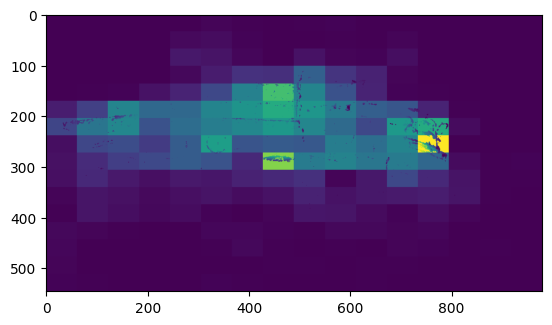

In [49]:
num_depth_buf.to_numpy().view(np.uint32)
plt.imshow(num_depth_buf.to_numpy().view(np.uint32))

In [50]:
ker_bwd_rasterize.dispatch(
    thread_count=[camera.sensor_size.x, camera.sensor_size.y, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_tile_hist": hist_buf,
        "g_tile_offs": tile_offst_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
        "g_render_target": render_target,
        "g_num_rendered_gaussians": num_depth_buf,
        "d_render_target": grad_texture,
        "d_a_gaussian_2d_sorted": a_gaussian_2d_sorted_grad_buf,
        
    }
)

[WARN] (rhi) slang: /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/./renderer/rasterizer.slang(126): error 55204: intrinsic operation 'floating point atomic operation' is not supported for the current target.
      d_a_gaussian_2d_sorted[i][j].add(d[j]);
                                      ^
metal 32023.619: /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/./renderer/rasterizer.slang(126): warning :  unused variable '_S70' [-Wunused-variable]
                float _S70 = atomic_fetch_add_explicit(&(*((&kernelContext_0)->d_a_gaussian_2d_sorted_0+i_0))[j_0], _S69[j_0], memory_order_relaxed);
                      ^
1 warning generated.



In [51]:
ker_grad_descent.dispatch(
    thread_count=[num_table_entries, 1, 1],
    lr=1e-2,
    vars={
        "d_a_gaussian_2d_sorted": a_gaussian_2d_sorted_grad_buf,
        
    }
)

[WARN] (rhi) slang: /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/gaussian.slang(163): error 55204: intrinsic operation 'floating point atomic operation' is not supported for the current target.
    this.position = float3(atomicGaussian[0].load(), atomicGaussian[1].load(),
                                                 ^
/Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/gaussian.slang(163): error 55204: intrinsic operation 'floating point atomic operation' is not supported for the current target.
    this.position = float3(atomicGaussian[0].load(), atomicGaussian[1].load(),
                                                                           ^
/Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/gaussian.slang(164): error 55204: intrinsic operation 'floating point atomic operation' is not supported for the current target.
                           atomicGaussian[2].load());
                                                 ^
/Users/fangjun/Documents/stanford/

## A Very Simple Gradient Descent

In [52]:
num_epoch = 64
lr = 10


for epoch in range(num_epoch):
    print(f"Epoch {epoch + 1}/{num_epoch}")

    ker_rasterize.dispatch(
        thread_count=[camera.sensor_size.x, camera.sensor_size.y, 1],
        vars={
            "g_camera": camera.to_slang(),
            "g_tile_hist": hist_buf,
            "g_tile_offs": tile_offst_buf,
            "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
            "g_render_target": render_target,
            "g_depth_target": depth_target,
            "g_num_rendered_gaussians": num_depth_buf,
        }
    )
    raw_image = jnp.array(render_target.to_numpy()[:, :, :3])
    loss, render_target_grad = loss_grad(raw_image, image_arr)

    print(f"Loss after gradient descent: {loss}")

    rg_shape = render_target_grad.shape
    render_target_grad = jnp.concatenate((render_target_grad, jnp.zeros((rg_shape[0], rg_shape[1], 1))), axis=-1)
    
    a_gaussian_2d_sorted_grad_buf.copy_from_numpy(
        np.zeros((a_gaussian_2d_sorted_grad_buf.size,), dtype=np.uint8))
    
    grad_texture.copy_from_numpy(render_target_grad)
    
    ker_bwd_rasterize.dispatch(
        thread_count=[camera.sensor_size.x, camera.sensor_size.y, 1],
        vars={
            "g_camera": camera.to_slang(),
            "g_tile_hist": hist_buf,
            "g_tile_offs": tile_offst_buf,
            "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
            "g_render_target": render_target,
            "d_render_target": grad_texture,
            "d_a_gaussian_2d_sorted": a_gaussian_2d_sorted_grad_buf,
            "g_num_rendered_gaussians": num_depth_buf,
        }
    )
    
    ker_grad_descent.dispatch(
        thread_count=[num_table_entries, 1, 1],
        lr=lr,
        vars={
            "d_a_gaussian_2d_sorted": a_gaussian_2d_sorted_grad_buf,
            "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
        }
    )
    
    gd = a_gaussian_2d_sorted_grad_buf.to_numpy().view(np.float32)
    print(f"Max gradient: {np.max(gd)}", f"Min gradient: {np.min(gd)}")


Epoch 1/64
Loss after gradient descent: 0.3720806837081909
Max gradient: 0.007446414325386286 Min gradient: -0.003662966890260577
Epoch 2/64
Loss after gradient descent: 0.3601731061935425
Max gradient: 0.003164323978126049 Min gradient: -0.0031570768915116787
Epoch 3/64
Loss after gradient descent: 0.3555096983909607
Max gradient: 0.009427573531866074 Min gradient: -0.003537008073180914
Epoch 4/64
Loss after gradient descent: 0.35288915038108826
Max gradient: 0.003790162270888686 Min gradient: -0.0038129822351038456
Epoch 5/64
Loss after gradient descent: 0.35106927156448364
Max gradient: 0.0034852675162255764 Min gradient: -0.0035064099356532097
Epoch 6/64
Loss after gradient descent: 0.34977659583091736
Max gradient: 0.003425321774557233 Min gradient: -0.003510551992803812
Epoch 7/64
Loss after gradient descent: 0.3487131595611572
Max gradient: 0.0026024305261671543 Min gradient: -0.0026108482852578163
Epoch 8/64
Loss after gradient descent: 0.34791383147239685
Max gradient: 0.00449

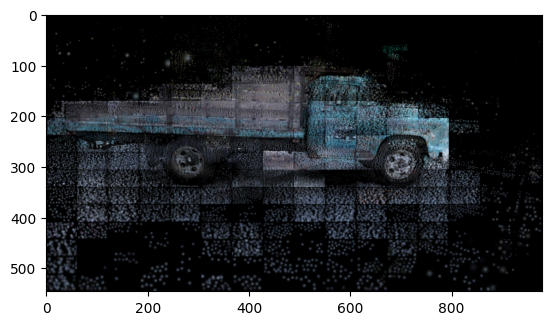

In [53]:
plt.imshow(raw_image)